# CSI Pickle Slice Visualizer

This notebook loads a small number of 5G CSI `.pickle` files, converts `x['ch_est']` into the `H` tensor layout used in `dataset_preparation.py`, and plots selected 2D slices for data visualization.

## Expected `H` layout
Your pipeline does:

```python
H = np.squeeze(np.array(x['ch_est']), axis=1)
```

This should yield:

`H.shape == (n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols)`

For the dataset you pointed to, I observed:

`H.shape = (4, 4, 1, 3276, 3)`

## How to use
1. Edit `DATASET_BASE`, `SPLIT`, `LABELS`, and `N_PICKLES_PER_LABEL` in the config cell.
2. Run the loading cell.
3. In the plotting cell, set `sample_i` and slice indices like `oru_idx`, `rx_ant_idx`, `tx_ant_idx`.
4. Change `freq_start/freq_end` to zoom into the most interesting frequency range.


In [5]:
import os
import glob
import pickle
import random

import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

# --------------------
# Config (edit me)
# --------------------
DATASET_BASE = '/scratch/bsc26f18/datasets/device_classification_2025_11_15'
SPLIT = 'all'  # 'training' or 'testing'

# Choose which device folders (labels) to sample from.
LABELS = ['iPhone16e', 'OnePlusNord', 'pixel7', 'sgs23']

# How many pickle files to load per label (keep it small for interactive plotting).
N_PICKLES_PER_LABEL = 2

# Selection strategy: 'first' (sorted filenames) or 'random'.
SELECTION_STRATEGY = 'n_sorted_after_m_samples'
my_rng = random.Random(1)

n_dmrs_symbols = 3
n_prbs = 273
n_tx_ant = 1

def list_pickles_for_label(dataset_base: str, split: str, label: str, debug: bool = False):
    """Return sorted list of pickle paths for a given label."""
    pattern = os.path.join(dataset_base, split, label, '*.pickle')
    print("Pattern: ", pattern)
    paths = glob.glob(pattern)
    # Using float because there is no double type in Python. Float has already double precision.
    sorted_paths = sorted(paths, key=lambda p: float(os.path.basename(p).split('_')[0]))
    return sorted_paths


def select_subset_with_indices(paths, n: int, strategy: str, rng: random.Random, m: int = 0):
    """Select paths while keeping pre-rng indices within the sorted `paths` list."""
    if n is None or n >= len(paths):
        chosen_indices = list(range(len(paths)))
    elif strategy == 'first':
        chosen_indices = list(range(n))
    elif strategy == 'n_sorted_after_m_samples':
        chosen_indices = list(range(n+m))[m:]
    elif strategy == 'random':
        chosen_indices = rng.sample(range(len(paths)), k=n)
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    chosen_paths = [paths[i] for i in chosen_indices]
    return chosen_paths, chosen_indices


In [ ]:
# LOAD PICKLE FILES

samples = []
sample_paths = []
sample_rec_arr = []
sample_dicts = np.zeros((len(LABELS), N_PICKLES_PER_LABEL), dtype=object)
H_list = []

for i, label in enumerate(LABELS):

    working_dict = sample_dicts[i]

    all_paths = list_pickles_for_label(DATASET_BASE, SPLIT, label, debug=True)
    if not all_paths:
        raise FileNotFoundError(f"No pickle files found for label='{label}' under {DATASET_BASE}/{SPLIT}")
    chosen, chosen_indices = select_subset_with_indices(all_paths, N_PICKLES_PER_LABEL, SELECTION_STRATEGY, my_rng, m=1000)
    print(f"Label={label}: found {len(all_paths)} pickles, selected {len(chosen)}")
    
    i=0
    for p, pre_rng_idx in zip(chosen, chosen_indices):
        with open(p, 'rb') as f:
            x = pickle.load(f)
    
        # Match dataset_preparation.py behavior
        h_arr = np.array(x['ch_est'])
        H = np.squeeze(h_arr, axis=1) # [n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols]
        H_list.append(H)
    
        # Useful debug info
        sample_rec_arr.append([label, pre_rng_idx, p])
        base = os.path.basename(p)
        sample_paths.append(base)

        rec = {
            'pickle_path': p,
            'label': label,
            'pre_rng_index_within_label': pre_rng_idx,
            'raw csi': h_arr,
            'H': H
        }
        working_dict[i] = rec
        i+=1
        #print(f"\npre_rng_idx: {pre_rng_idx}")

H_list_stacked = np.stack(H_list, axis=0) # [len(LABELS)*N_PICKLES_PER_LABEL, n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols]
assert H_list_stacked.shape[0] == len(LABELS) * N_PICKLES_PER_LABEL

H_all = np.reshape(H_list_stacked, [len(LABELS), N_PICKLES_PER_LABEL, *H_list_stacked.shape[1:]])
# H_all has dimension: [len(LABELS), N_PICKLES_PER_LABEL, n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols]

# check whether reshape is correct
flat_idx = 0
for i in range(len(LABELS)):
    for j in range(N_PICKLES_PER_LABEL):
        # uses np.all under the hood to make sure that all elements are compared
        assert np.allclose(H_all[i, j], sample_dicts[i, j]['H'], atol=1e-6), f"Mismatch 1 at Label {i}, Sample {j}"
        assert np.allclose(H_all[i, j], H_list_stacked[flat_idx], atol=1e-6), f"Mismatch 2 at Label {i}, Sample {j}"
        flat_idx += 1

print("Reshape assertion passed successfully!")

print('\nTotal loaded samples:', len(sample_rec_arr))
if len(sample_rec_arr) == 0:
    raise RuntimeError('No samples loaded')

print('Labels:', sorted(set(s[0] for s in sample_rec_arr)))
#print('Ensure randomness:', sorted(set(s[1] for s in sample_rec_arr)))
#print('\nH_all shape:', H_all.shape)


Pattern:  /scratch/bsc26f18/datasets/device_classification_2025_11_15/all/iPhone16e/*.pickle
Label=iPhone16e: found 15251 pickles, selected 2

pre_rng_idx: 1000

pre_rng_idx: 1001
Pattern:  /scratch/bsc26f18/datasets/device_classification_2025_11_15/all/OnePlusNord/*.pickle
Label=OnePlusNord: found 19751 pickles, selected 2

pre_rng_idx: 1000

pre_rng_idx: 1001
Pattern:  /scratch/bsc26f18/datasets/device_classification_2025_11_15/all/pixel7/*.pickle
Label=pixel7: found 17486 pickles, selected 2

pre_rng_idx: 1000

pre_rng_idx: 1001
Pattern:  /scratch/bsc26f18/datasets/device_classification_2025_11_15/all/sgs23/*.pickle
Label=sgs23: found 18357 pickles, selected 2

pre_rng_idx: 1000

pre_rng_idx: 1001
Reshape assertion passed successfully!

Total loaded samples: 8
Labels: ['OnePlusNord', 'iPhone16e', 'pixel7', 'sgs23']


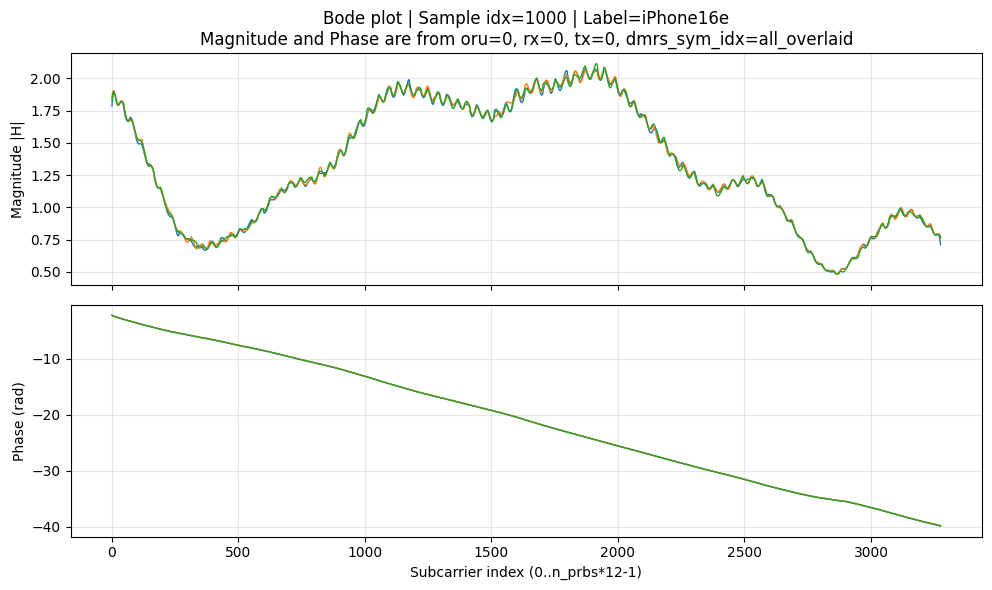

Rec pickle: /scratch/bsc26f18/datasets/device_classification_2025_11_15/all/iPhone16e/1763202564.402_26473.pickle
Plotted frequency bins: 0..3275


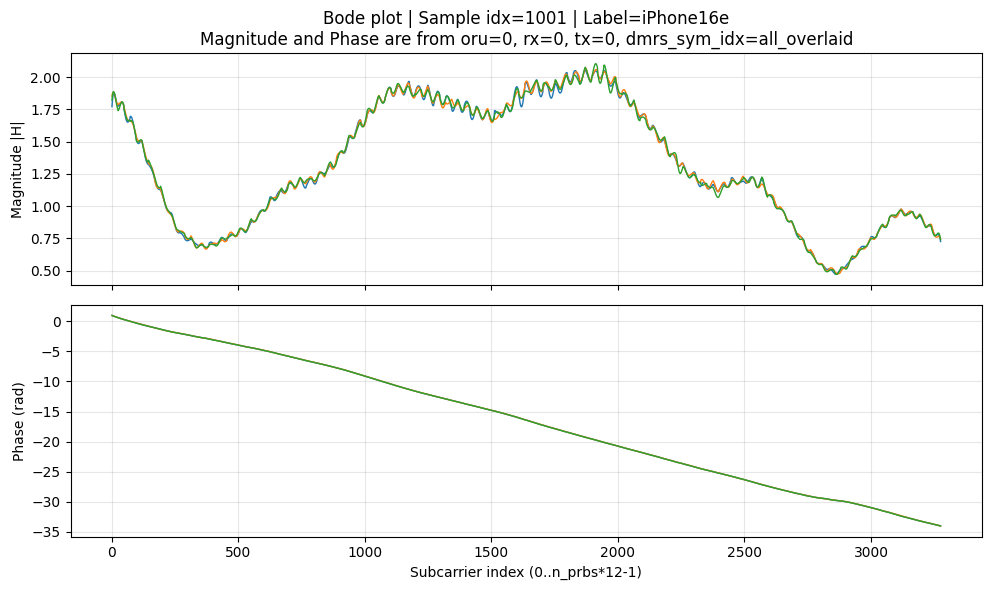

Rec pickle: /scratch/bsc26f18/datasets/device_classification_2025_11_15/all/iPhone16e/1763202564.412_26473.pickle
Plotted frequency bins: 0..3275


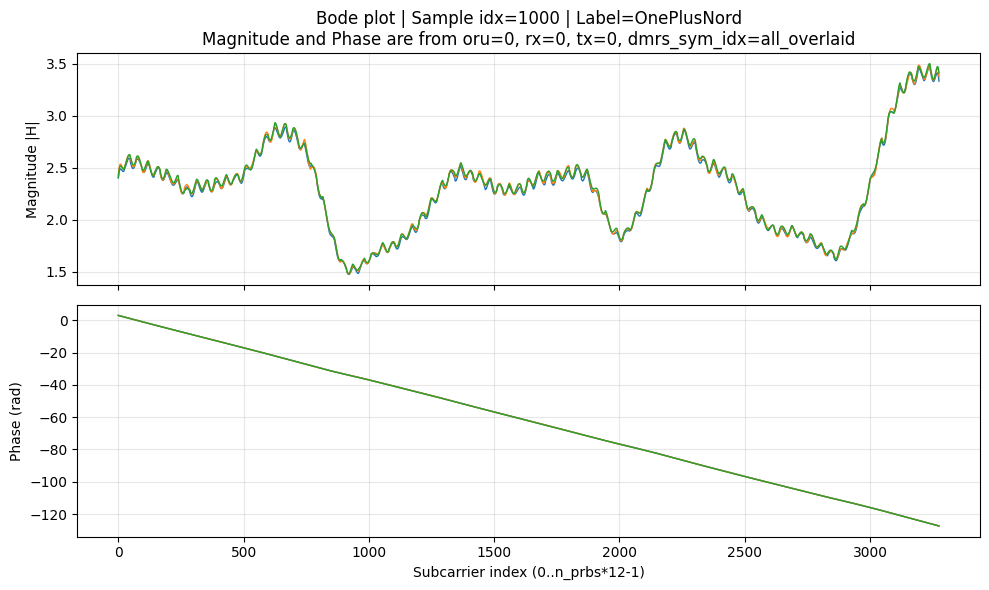

Rec pickle: /scratch/bsc26f18/datasets/device_classification_2025_11_15/all/OnePlusNord/1763203634.387_57966.pickle
Plotted frequency bins: 0..3275


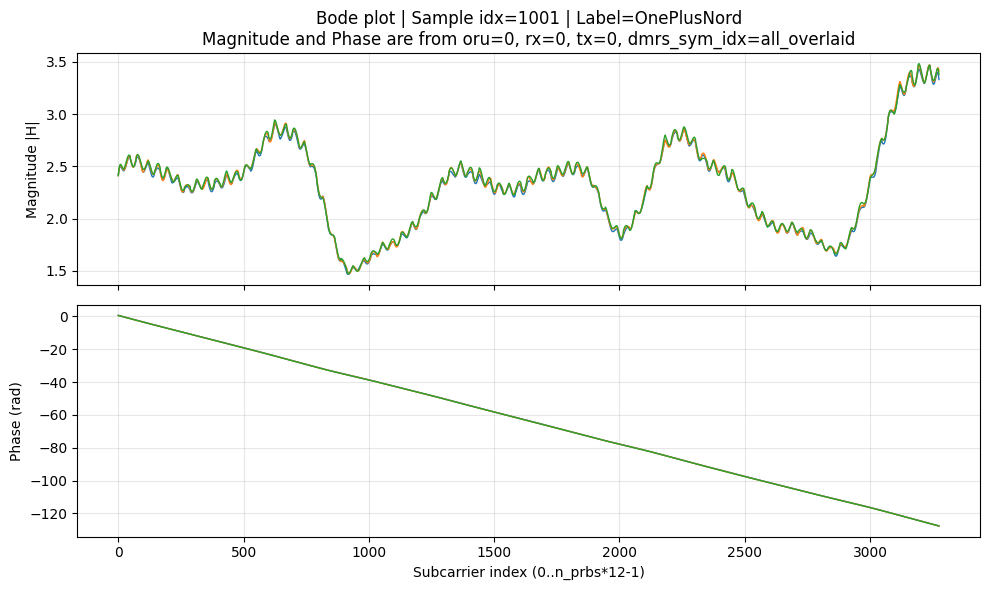

Rec pickle: /scratch/bsc26f18/datasets/device_classification_2025_11_15/all/OnePlusNord/1763203634.392_57966.pickle
Plotted frequency bins: 0..3275


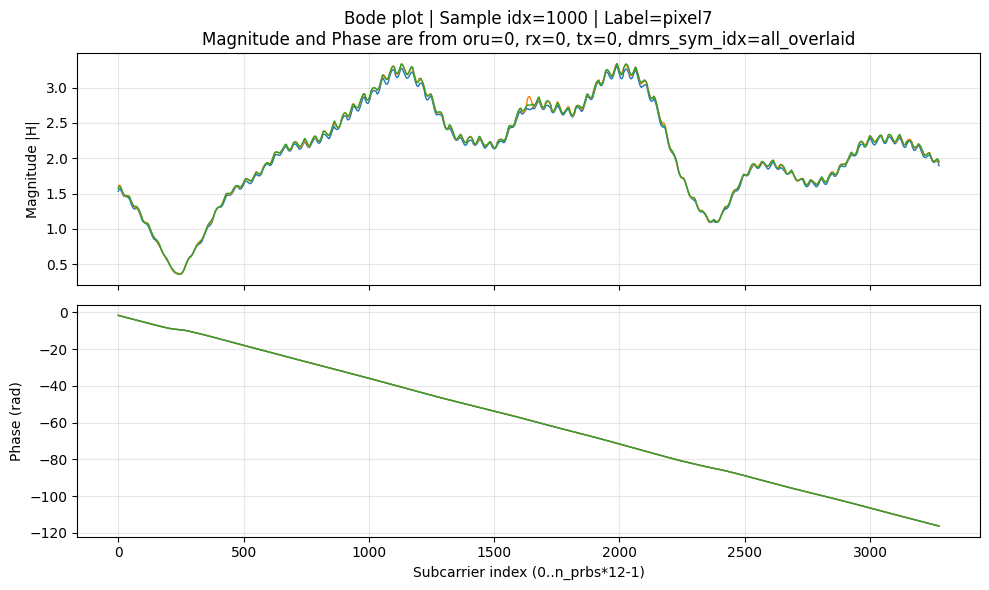

Rec pickle: /scratch/bsc26f18/datasets/device_classification_2025_11_15/all/pixel7/1763202881.102_48032.pickle
Plotted frequency bins: 0..3275


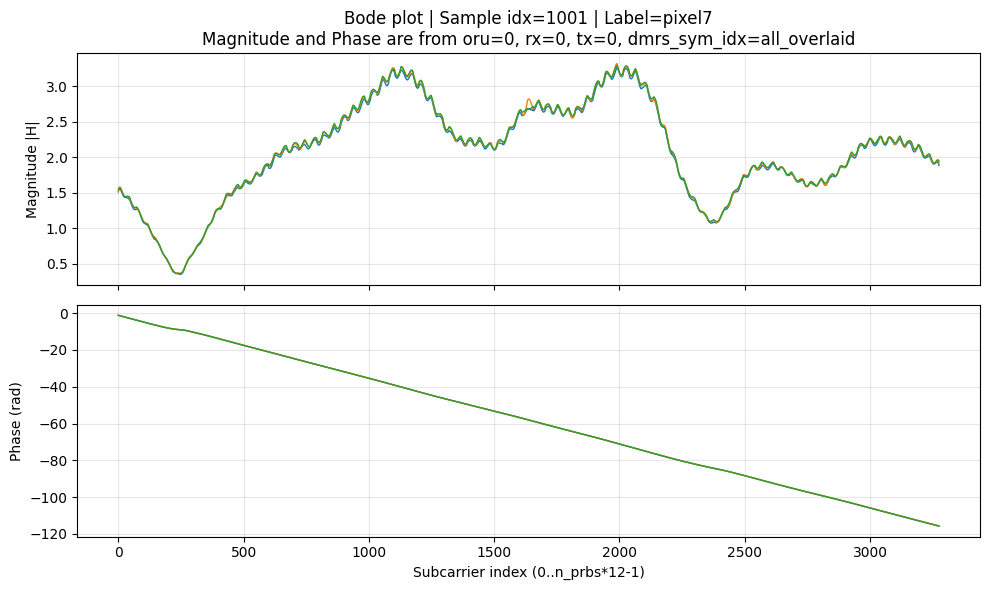

Rec pickle: /scratch/bsc26f18/datasets/device_classification_2025_11_15/all/pixel7/1763202881.112_48032.pickle
Plotted frequency bins: 0..3275


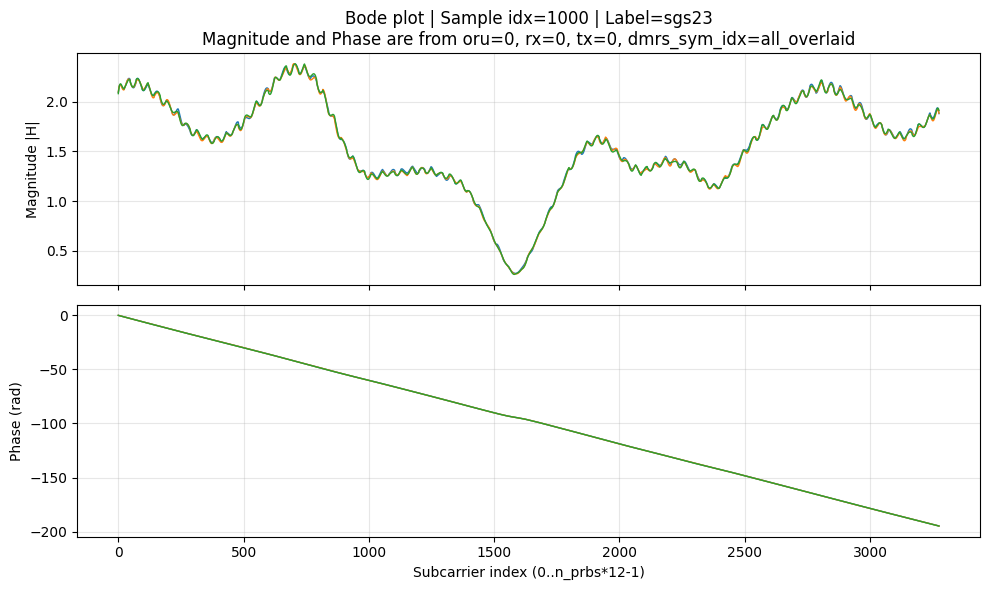

Rec pickle: /scratch/bsc26f18/datasets/device_classification_2025_11_15/all/sgs23/1763203294.542_53579.pickle
Plotted frequency bins: 0..3275


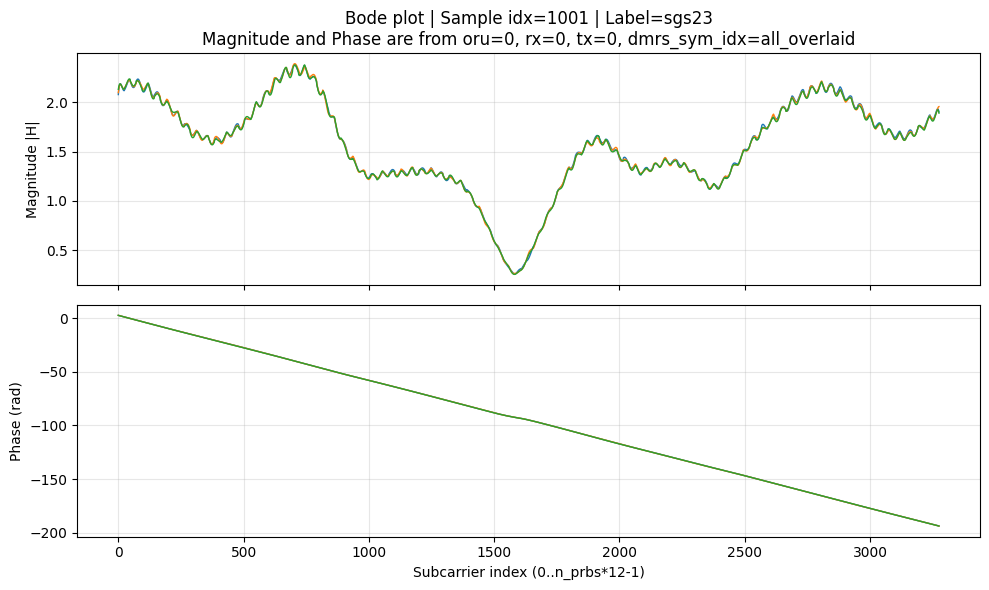

Rec pickle: /scratch/bsc26f18/datasets/device_classification_2025_11_15/all/sgs23/1763203294.552_53579.pickle
Plotted frequency bins: 0..3275


In [ ]:
# --------------------
# Bode-style magnitude + phase
# --------------------

# Pick which loaded sample to visualize
#sample_i = 0  # index into `samples`

# Slice indices across H axes:
#   H[oru_idx, rx_ant_idx, tx_ant_idx, freq_bins, dmrs_symbols]
oru_idx = 0
rx_ant_idx = 0
tx_ant_idx = 0


# Fixed DMRS symbol (time-axis index)
#dmrs_sym_idx = 0

# Frequency-bin slice (index range, not physical Hz)
freq_start_bode = 0
freq_end_bode = None  # set to an int to zoom

eps = globals().get('eps', 1e-12)

for label_idx, label in enumerate(LABELS):
    for sample_i in range(N_PICKLES_PER_LABEL):

        # H has shape [n_orus, n_rx_ant_per_oru, n_tx_ant, n_prbs*12, n_dmrs_symbols]
        H = H_all[label_idx, sample_i]

        # take phase and mag of only one Rx antenna
        H_line = H[oru_idx, rx_ant_idx, tx_ant_idx, :, :]  # (freq_bins)

        phase_dmrs0 = np.angle(H_line[:, 0])
        phase_dmrs1 = np.angle(H_line[:, 1])
        phase_dmrs2 = np.angle(H_line[:, 2])

        mag_dmrs0 = np.abs(H_line[:, 0])
        mag_dmrs1 = np.abs(H_line[:, 1])
        mag_dmrs2 = np.abs(H_line[:, 2])

        phase_dmrs0 = np.unwrap(phase_dmrs0)
        phase_dmrs1 = np.unwrap(phase_dmrs1)
        phase_dmrs2 = np.unwrap(phase_dmrs2)

        phase_dmrs0_plot = phase_dmrs0
        phase_dmrs1_plot = phase_dmrs1
        phase_dmrs2_plot = phase_dmrs2

        fs = 0 if freq_start_bode is None else int(freq_start_bode)
        fe = H_line.shape[0] if freq_end_bode is None else int(freq_end_bode)

        fs = max(0, fs)
        fe = min(H_line.shape[0], fe)
        if fe <= fs:
            raise ValueError(f"Invalid bode slice: fs={fs}, fe={fe}")

        f_bins = np.arange(fs, fe)
        mag_dmrs0_slice = mag_dmrs0[fs:fe]
        mag_dmrs1_slice = mag_dmrs1[fs:fe]
        mag_dmrs2_slice = mag_dmrs2[fs:fe]

        phase_dmrs0_slice = phase_dmrs0[fs:fe]
        phase_dmrs1_slice = phase_dmrs1[fs:fe]
        phase_dmrs2_slice = phase_dmrs2[fs:fe]

        mag_dmrs0_plot = mag_dmrs0_slice
        mag_dmrs1_plot = mag_dmrs1_slice
        mag_dmrs2_plot = mag_dmrs2_slice

        mag_ylabel = 'Magnitude |H|'

        # Plot: 2 stacked panels (Bode-style)
        fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

        axes[0].plot(f_bins, mag_dmrs0_plot, linewidth=1.0)
        axes[0].plot(f_bins, mag_dmrs1_plot, linewidth=1.0)
        axes[0].plot(f_bins, mag_dmrs2_plot, linewidth=1.0)
        axes[0].grid(True, alpha=0.3)
        axes[0].set_ylabel(mag_ylabel)
        axes[0].set_title(
            f"Bode plot | Sample idx={sample_rec_arr[label_idx*N_PICKLES_PER_LABEL+sample_i][1]} | Label={label}\n"
            f"Magnitude and Phase are from oru={oru_idx}, rx={rx_ant_idx}, tx={tx_ant_idx}, dmrs_sym_idx=all_overlaid"
        )

        axes[1].plot(f_bins, phase_dmrs0_plot, linewidth=1.0)
        axes[1].plot(f_bins, phase_dmrs1_plot, linewidth=1.0)
        axes[1].plot(f_bins, phase_dmrs2_plot, linewidth=1.0)
        axes[1].grid(True, alpha=0.3)
        axes[1].set_ylabel('Phase (rad)')
        axes[1].set_xlabel('Subcarrier index (0..n_prbs*12-1)')

        plt.tight_layout()

        out_name = (
            f"bode_raw_{label}_sample_{sample_rec_arr[label_idx*N_PICKLES_PER_LABEL+sample_i][1]}"
            f"_dmrs_overlay.png"
        )
        plt.savefig(out_name, dpi=300, bbox_inches='tight')
        plt.show()

        print('Rec pickle:', sample_rec_arr[label_idx*N_PICKLES_PER_LABEL+sample_i][2])
        #print('H_sel_local.shape:', H_sel_local.shape, '(freq_bins, dmrs_symbols)')
        print(f'Plotted frequency bins: {fs}..{fe-1}')


In [ ]:
# THIS CELL COMPUTES THE COSINE DISSIMILARITY HISTOGRAM OF THE RAW CSI PHASES

oru_idx = 0
rx_ant_idx = 0
tx_ant_idx = 0

# Average over DMRS symbols because they are very similar
H_cosine_dissimilarity = np.mean(H_list_stacked, axis=-1)
H_cosine_dissimilarity = H_cosine_dissimilarity[:,oru_idx,rx_ant_idx,tx_ant_idx,:]
assert H_cosine_dissimilarity.shape == (len(LABELS)*N_PICKLES_PER_LABEL, 12*n_prbs), "flattening error"

X = H_cosine_dissimilarity
G = X @ X.conj().T

norms = np.sqrt(np.sum(np.abs(X)**2, axis=1, keepdims=True))
cos_sim = np.abs(G) / (norms @ norms.T)
D_cos = 1.0 - cos_sim
D_cos = np.maximum(D_cos, 0.0)



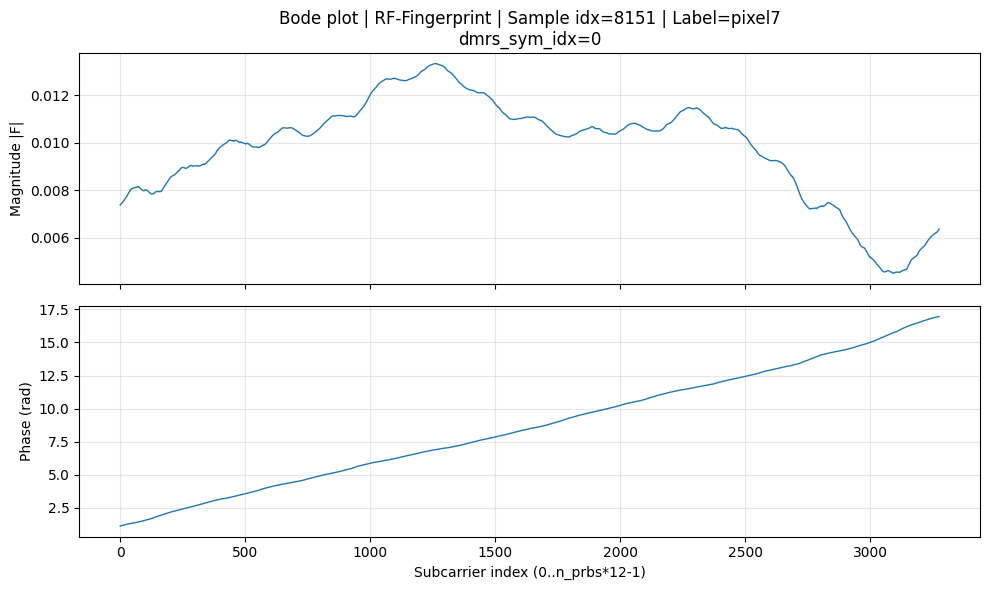

Rec pickle: /scratch/bsc26f18/datasets/device_classification_2025_11_15/training/pixel7/1763202948.982_48032.pickle
Plotted frequency bins: 0..3275


In [13]:
# --------------------
# Bode-style magnitude + phase for a fixed DMRS symbol (for Fingerprints!)
# --------------------

# Pick which loaded sample to visualize
sample_i = 0  # index into `samples`

# Slice indices across H axes:
#   H[oru_idx, rx_ant_idx, tx_ant_idx, freq_bins, dmrs_symbols]
oru_idx = 0
rx_ant_idx = 0
tx_ant_idx = 0


# Fixed DMRS symbol (time-axis index)
dmrs_sym_idx = 0

# Frequency-bin slice (index range, not physical Hz)
freq_start_bode = 0
freq_end_bode = None  # set to an int to zoom

# Magnitude scaling: 'linear', 'log10', or 'db'
magnitude_mode = 'linear'

# Phase plotting options
unwrap_phase = True
phase_in_degrees = False

eps = globals().get('eps', 1e-12)

rec = samples[sample_i]
feature_vec = rec['feature_vec']

# Complex response across frequency for a single DMRS symbol
feature_vec = feature_vec[:, dmrs_sym_idx]  # (freq_bins,)

mag = np.abs(feature_vec)
phase = np.angle(feature_vec)

if unwrap_phase:
    phase = np.unwrap(phase)

phase_plot = np.degrees(phase) if phase_in_degrees else phase

fs = 0 if freq_start_bode is None else int(freq_start_bode)
fe = feature_vec.shape[0] if freq_end_bode is None else int(freq_end_bode)

fs = max(0, fs)
fe = min(feature_vec.shape[0], fe)
if fe <= fs:
    raise ValueError(f"Invalid bode slice: fs={fs}, fe={fe}")

f_bins = np.arange(fs, fe)
mag_slice = mag[fs:fe]
phase_slice = phase_plot[fs:fe]

if magnitude_mode == 'linear':
    mag_plot = mag_slice
    mag_ylabel = 'Magnitude |F|'
elif magnitude_mode == 'log10':
    mag_plot = np.log10(mag_slice + eps)
    mag_ylabel = 'log10(|F|)'
elif magnitude_mode == 'db':
    mag_plot = 20.0 * np.log10(mag_slice + eps)
    mag_ylabel = 'Magnitude (dB, 20log10|F|)'
else:
    raise ValueError(f"Unknown magnitude_mode: {magnitude_mode}")

# Plot: 2 stacked panels (Bode-style)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(f_bins, mag_plot, linewidth=1.0)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylabel(mag_ylabel)
axes[0].set_title(
    f"Bode plot | RF-Fingerprint | Sample idx={rec['pre_rng_index_within_label']} | Label={rec['label']}\n"
    f"dmrs_sym_idx={dmrs_sym_idx}"
)

axes[1].plot(f_bins, phase_slice, linewidth=1.0)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylabel('Phase (deg)' if phase_in_degrees else 'Phase (rad)')
axes[1].set_xlabel('Subcarrier index (0..n_prbs*12-1)')

plt.tight_layout()

out_name = (
    f"bode_{magnitude_mode}_fingerprint_{rec['label']}_sample_{rec['pre_rng_index_within_label']}"
    f"_dmrs_0.png"
)
plt.savefig(out_name, dpi=300, bbox_inches='tight')
plt.show()

print('Rec pickle:', rec['pickle_path'])
#print('H_sel_local.shape:', H_sel_local.shape, '(freq_bins, dmrs_symbols)')
print(f'Plotted frequency bins: {fs}..{fe-1}')


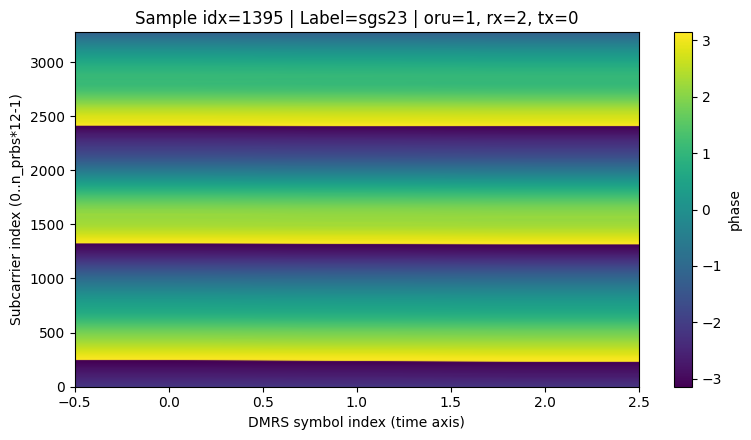

Rec pickle: /scratch/bsc26f18/datasets/device_classification_2025_11_15/training/sgs23/1763203297.182_53579.pickle
H.shape: (4, 4, 1, 3276, 3)
H_sel.shape: (3276, 3) (freq_bins, dmrs_symbols)
Plotted range: freq 0 to 3275 | time 0 to 2


In [172]:
# --------------------
# Plot a selected 2D slice
# --------------------
# Pick which loaded sample to visualize
sample_i = 0  # index into `samples`

# Slice indices across H axes:
#   H[oru_idx, rx_ant_idx, tx_ant_idx, freq_bins, dmrs_symbols]
oru_idx = 1
rx_ant_idx = 2
tx_ant_idx = 0

# Frequency and time ranges (both are index ranges, not physical units)
freq_start = 0
freq_end = None  # set to None to plot all 3276 bins
time_start = 0
time_end = None

# What quantity to visualize
#   'magnitude', 'phase'
plot_quantity = 'phase'

# Optionally log-scale magnitude/power for better contrast
use_log_scale = False
eps = 1e-12


def to_quantity(H_complex, quantity: str):
    if quantity == 'magnitude':
        return np.abs(H_complex)
    if quantity == 'phase':
        return np.angle(H_complex)
    raise ValueError(f"Unknown plot_quantity: {quantity}")


rec = samples[sample_i]
H = rec['H']

H_sel = H[oru_idx, rx_ant_idx, tx_ant_idx, :, :]

q = to_quantity(H_sel, plot_quantity)

fs = 0 if freq_start is None else int(freq_start)
fe = q.shape[0] if freq_end is None else int(freq_end)
ts = 0 if time_start is None else int(time_start)
te = q.shape[1] if time_end is None else int(time_end)

q_plot = q[fs:fe, ts:te]

if use_log_scale:
    q_plot = np.log10(q_plot + eps)

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(q_plot, aspect='auto', origin='lower')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(f"{plot_quantity}{' (log10)' if use_log_scale else ''}")

ax.set_title(f"Sample idx={rec['pre_rng_index_within_label']} | Label={rec['label']} | oru={oru_idx}, rx={rx_ant_idx}, tx={tx_ant_idx}")
ax.set_xlabel('DMRS symbol index (time axis)')
ax.set_ylabel('Subcarrier index (0..n_prbs*12-1)')

plt.tight_layout()

plt.savefig(f"{plot_quantity}_raw_{rec['label']}_sample_{rec['pre_rng_index_within_label']}_oru_{oru_idx}_rx_{rx_ant_idx}.png", dpi=300, bbox_inches='tight')

plt.show()

print('Rec pickle:', rec['pickle_path'])
print('H.shape:', rec['H_shape'])
print('H_sel.shape:', H_sel.shape, '(freq_bins, dmrs_symbols)')
print('Plotted range: freq', fs, 'to', fe - 1, '| time', ts, 'to', te - 1)


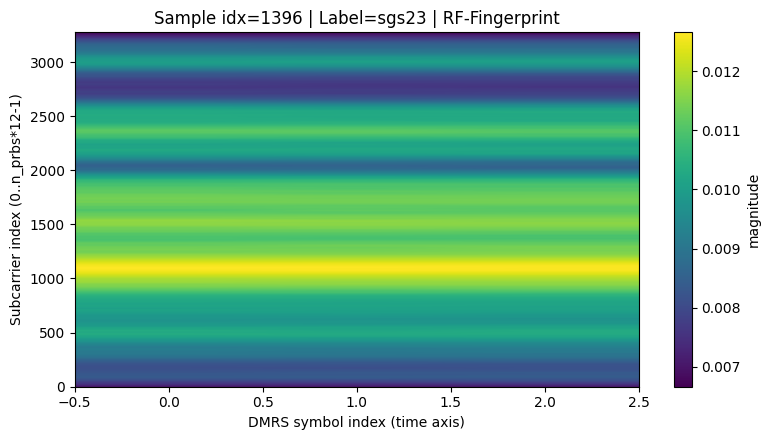

Rec pickle: /scratch/bsc26f18/datasets/device_classification_2025_11_15/training/sgs23/1763203297.192_53579.pickle
features.shape: (3276, 3)
Plotted range: freq 0 to 3275 | time 0 to 2


In [184]:
# --------------------
# Plot a selected 2D slice
# --------------------
# Pick which loaded sample to visualize
sample_i = 0  # index into `samples`

# Slice indices across H axes:
#   H[oru_idx, rx_ant_idx, tx_ant_idx, freq_bins, dmrs_symbols]
oru_idx = 0
rx_ant_idx = 0
tx_ant_idx = 0

# Frequency and time ranges (both are index ranges, not physical units)
freq_start = 0
freq_end = None  # set to None to plot all 3276 bins
time_start = 0
time_end = None

# What quantity to visualize
#   'magnitude', 'phase'
plot_quantity = 'magnitude'

# Optionally log-scale magnitude/power for better contrast
use_log_scale = False
eps = 1e-12


def to_quantity(H_complex, quantity: str):
    if quantity == 'magnitude':
        return np.abs(H_complex)
    if quantity == 'phase':
        return np.angle(H_complex)
    raise ValueError(f"Unknown plot_quantity: {quantity}")


rec = samples[sample_i]
feature_vec = rec['feature_vec']

q = to_quantity(feature_vec, plot_quantity)

fs = 0 if freq_start is None else int(freq_start)
fe = q.shape[0] if freq_end is None else int(freq_end)
ts = 0 if time_start is None else int(time_start)
te = q.shape[1] if time_end is None else int(time_end)

q_plot = q[fs:fe, ts:te]

if use_log_scale:
    q_plot = np.log10(q_plot + eps)

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(q_plot, aspect='auto', origin='lower')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(f"{plot_quantity}{' (log10)' if use_log_scale else ''}")

ax.set_title(f"Sample idx={rec['pre_rng_index_within_label']} | Label={rec['label']} | RF-Fingerprint")
ax.set_xlabel('DMRS symbol index (time axis)')
ax.set_ylabel('Subcarrier index (0..n_prbs*12-1)')

plt.tight_layout()

plt.savefig(f"{plot_quantity}_fingerprint_{rec['label']}_sample_{rec['pre_rng_index_within_label']}.png", dpi=300, bbox_inches='tight')

plt.show()

print('Rec pickle:', rec['pickle_path'])
print('features.shape:', rec['feature_vec'].shape)
print('Plotted range: freq', fs, 'to', fe - 1, '| time', ts, 'to', te - 1)


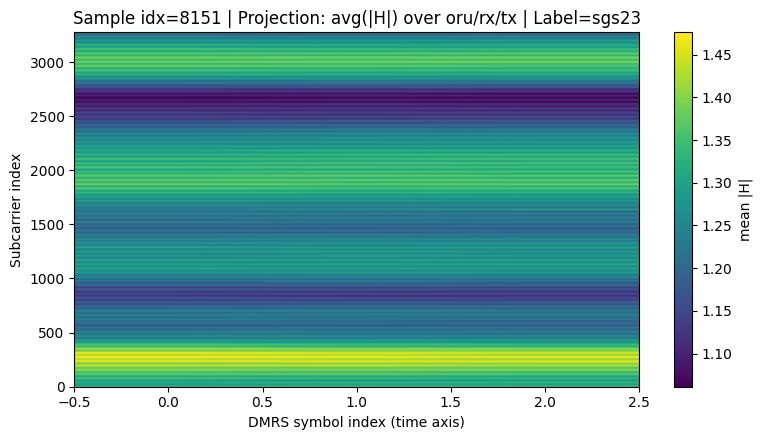

In [93]:
# --------------------
# Optional: projection of MAGNITUDE over antenna/AP axes
# --------------------
# This can be useful to see if there is any obvious per-frequency pattern.
sample_i = 0

rec = samples[sample_i]
H = rec['H']

# Average magnitude across (oru, rx_ant, tx_ant) -> (freq_bins, dmrs_symbols)
proj = np.mean(np.abs(H), axis=(0, 1, 2))

freq_start = 0
freq_end = None
time_start = 0
time_end = None

fs = 0 if freq_start is None else int(freq_start)
fe = proj.shape[0] if freq_end is None else int(freq_end)
ts = 0 if time_start is None else int(time_start)
te = proj.shape[1] if time_end is None else int(time_end)

proj_plot = proj[fs:fe, ts:te]

fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(proj_plot, aspect='auto', origin='lower')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('mean |H|')
ax.set_title(f"Sample idx={rec['pre_rng_index_within_label']} | Projection: avg(|H|) over oru/rx/tx | Label={rec['label']}")
ax.set_xlabel('DMRS symbol index (time axis)')
ax.set_ylabel('Subcarrier index')
plt.tight_layout()

plt.savefig(f"mag_projection_label_{rec['label']}_sample_{rec['pre_rng_index_within_label']}.png", dpi=300, bbox_inches='tight')

plt.show()
